In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Set plot style
sns.set_theme(style="whitegrid")

In [2]:
#Q1. (Understanding & Dataset Creation)
# Create synthetic dataset
X, y = make_blobs(
    n_samples=500, 
    centers=4, 
    cluster_std=0.70, 
    random_state=42
)

# Convert to DataFrame
df = pd.DataFrame(X, columns=['Feature1', 'Feature2'])

# Display first 10 rows and dataset shape
print("--- First 10 Rows ---")
print(df.head(10))

print("\n--- Dataset Shape ---")
print(df.shape)



--- First 10 Rows ---
   Feature1  Feature2
0 -8.033836  6.831299
1 -8.767448 -6.918116
2  6.172741  1.407361
3 -2.783673  7.989826
4 -6.038777 -7.165762
5 -6.298392 -7.479368
6 -7.046269  7.256281
7 -6.690307 -6.915276
8  3.892545  1.873504
9 -7.317000 -6.861846

--- Dataset Shape ---
(500, 2)


In [3]:
#Q2. (Data Scaling)
# Initialize and apply StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[['Feature1', 'Feature2']])

# Store as DataFrame for easy viewing
df_scaled = pd.DataFrame(X_scaled, columns=['Feature1_scaled', 'Feature2_scaled'])

# Show first 5 rows of scaled data
print("--- First 5 Rows of Scaled Data ---")
print(df_scaled.head(5))


--- First 5 Rows of Scaled Data ---
   Feature1_scaled  Feature2_scaled
0        -0.888474         0.629907
1        -1.028908        -1.562875
2         1.831069        -0.235113
3         0.116557         0.814671
4        -0.506563        -1.602370


In [4]:
#Q3. (Basic K-Means Clustering)
# Fit KMeans with n_clusters = 3
kmeans_k3 = KMeans(n_clusters=3, random_state=42, n_init='auto')
df['Cluster_K3'] = kmeans_k3.fit_predict(X_scaled)

# Display first 10 rows of updated DataFrame
print("--- First 10 Rows with Cluster Labels (K=3) ---")
print(df.head(10))

--- First 10 Rows with Cluster Labels (K=3) ---
   Feature1  Feature2  Cluster_K3
0 -8.033836  6.831299           1
1 -8.767448 -6.918116           2
2  6.172741  1.407361           0
3 -2.783673  7.989826           1
4 -6.038777 -7.165762           2
5 -6.298392 -7.479368           2
6 -7.046269  7.256281           1
7 -6.690307 -6.915276           2
8  3.892545  1.873504           0
9 -7.317000 -6.861846           2


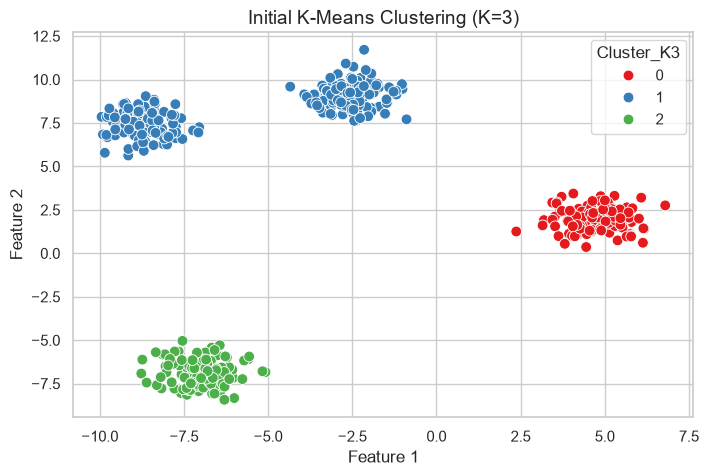

In [5]:
#Q4. (Visualizing Clusters)
# Scatter plot for initial K=3 clusters
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df, 
    x='Feature1', 
    y='Feature2', 
    hue='Cluster_K3', 
    palette='Set1', 
    s=60
)

plt.title('Initial K-Means Clustering (K=3)', fontsize=14)
plt.xlabel('Feature 1', fontsize=12)
plt.ylabel('Feature 2', fontsize=12)
plt.show()

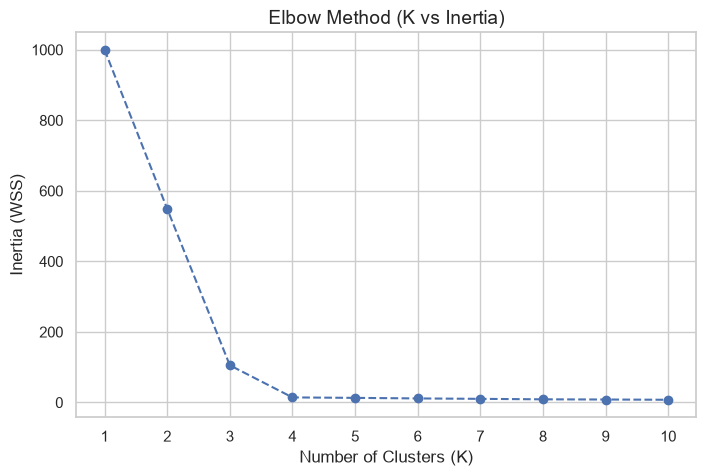

In [6]:
#Q5. (Elbow Method – Finding Optimal K)
# Calculate WSS (Inertia) for K from 1 to 10
wcss = []
k_range = range(1, 11)

for k in k_range:
    model = KMeans(n_clusters=k, random_state=42, n_init='auto')
    model.fit(X_scaled)
    wcss.append(model.inertia_)

# Plot Elbow graph
plt.figure(figsize=(8, 5))
plt.plot(k_range, wcss, marker='o', linestyle='--', color='b')
plt.title('Elbow Method (K vs Inertia)', fontsize=14)
plt.xlabel('Number of Clusters (K)', fontsize=12)
plt.ylabel('Inertia (WSS)', fontsize=12)
plt.xticks(k_range)
plt.show()

# Observation: The elbow/sharp bend is clearly visible at K = 4.

In [7]:
#Q6. (Final K-Means Model)
# Train final model with optimal K = 4
optimal_k = 4
final_kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init='auto')

# Predict and add labels
df['Final_Cluster'] = final_kmeans.fit_predict(X_scaled)

# Print count of data points in each cluster
print("--- Number of Data Points per Cluster (K=4) ---")
print(df['Final_Cluster'].value_counts().sort_index())

--- Number of Data Points per Cluster (K=4) ---
Final_Cluster
0    125
1    125
2    125
3    125
Name: count, dtype: int64


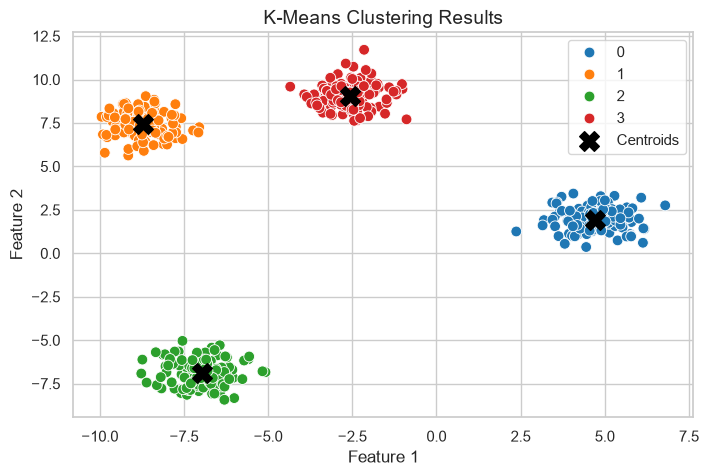

In [8]:
#Q7. (Visualizing Final Clusters)
# Get centroids in original feature scale
centroids_unscaled = scaler.inverse_transform(final_kmeans.cluster_centers_)

plt.figure(figsize=(8, 5))

# Plot data points
sns.scatterplot(
    data=df, 
    x='Feature1', 
    y='Feature2', 
    hue='Final_Cluster', 
    palette='tab10', 
    s=60
)

# Overlay centroids
plt.scatter(
    centroids_unscaled[:, 0], 
    centroids_unscaled[:, 1], 
    c='black', 
    s=200, 
    marker='X', 
    label='Centroids'
)

plt.title('K-Means Clustering Results', fontsize=14)
plt.xlabel('Feature 1', fontsize=12)
plt.ylabel('Feature 2', fontsize=12)
plt.legend()
plt.show()

In [9]:
#Q8. (Real Dataset Application)
# 1. Load your uploaded dataset
real_df = pd.read_csv('Mall_Customers.csv')

# 2. Select numerical features for clustering
X_real = real_df[['Annual Income (k$)', 'Spending Score (1-100)']]

# 3. Scale the data using StandardScaler
real_scaler = StandardScaler()
X_real_scaled = real_scaler.fit_transform(X_real)

# 4. Apply initial KMeans clustering (n_clusters = 3)
initial_real_kmeans = KMeans(n_clusters=3, random_state=42, n_init='auto')
real_df['Cluster_K3'] = initial_real_kmeans.fit_predict(X_real_scaled)

# 5. Display value counts for each cluster
print("--- Q8: Initial Cluster Counts (K=3) ---")
print(real_df['Cluster_K3'].value_counts().sort_index())

--- Q8: Initial Cluster Counts (K=3) ---
Cluster_K3
0    61
1    62
2    77
Name: count, dtype: int64


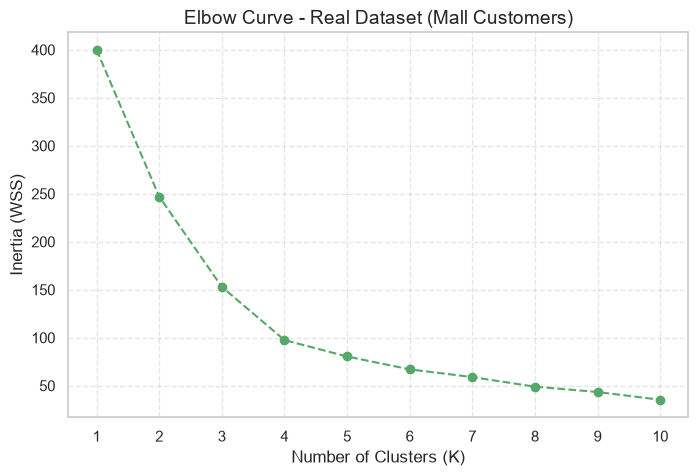

--- Q9: Final Cluster Counts (K=5) ---
Final_Cluster
0    56
1    35
2    34
3    37
4    38
Name: count, dtype: int64


In [10]:
#Q9. (Elbow Method on Real Dataset)
# 1. Load dataset & select features
real_df = pd.read_csv('Mall_Customers.csv')
X_real = real_df[['Annual Income (k$)', 'Spending Score (1-100)']]

# 2. Scale features
real_scaler = StandardScaler()
X_real_scaled = real_scaler.fit_transform(X_real)

# 3. Apply Elbow Method (K = 1 to 10)
real_wcss = []
k_range = range(1, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init='auto')
    km.fit(X_real_scaled)
    real_wcss.append(km.inertia_)

# 4. Plot Elbow Curve
plt.figure(figsize=(8, 5))
plt.plot(k_range, real_wcss, marker='o', color='g', linestyle='--')
plt.title('Elbow Curve - Real Dataset (Mall Customers)', fontsize=14)
plt.xlabel('Number of Clusters (K)', fontsize=12)
plt.ylabel('Inertia (WSS)', fontsize=12)
plt.xticks(k_range)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# 5. Train final model with optimal K = 5
optimal_k = 5
final_real_kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init='auto')
real_df['Final_Cluster'] = final_real_kmeans.fit_predict(X_real_scaled)

# 6. Display cluster sizes
print("--- Q9: Final Cluster Counts (K=5) ---")
print(real_df['Final_Cluster'].value_counts().sort_index())

--- Step 1: Dataset Overview ---
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB
None

First 5 Rows:
   CustomerID Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1   Male   19                 109                      36
1           2   Male   32                  32                      95
2           3   Male   61                 109                      70
3           4   Male   55                  69                       5
4           5   Male   23                  42                      30


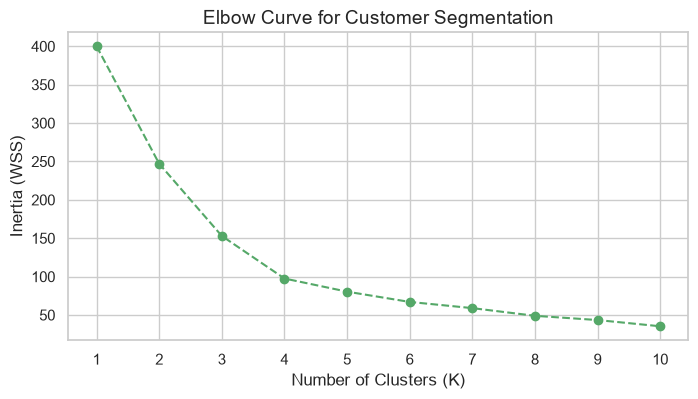

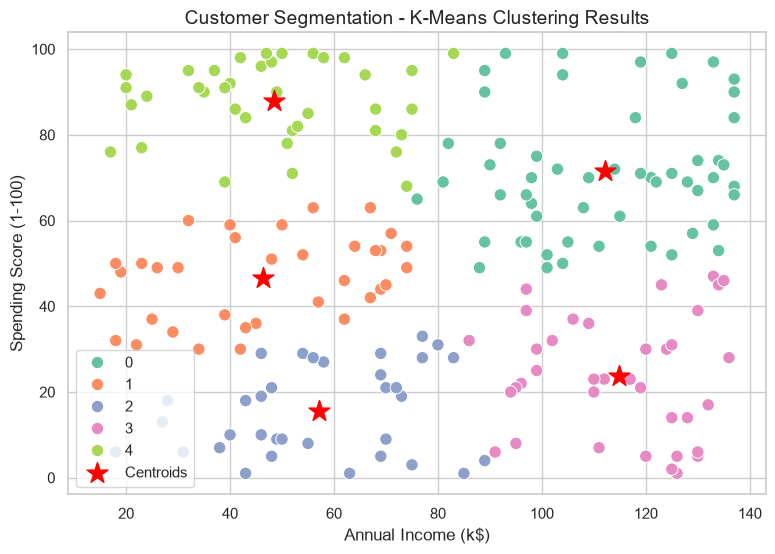


--- Step 6: Cluster Summary Analysis ---
               Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                       
0        44.107143          112.196429               71.500000
1        42.285714           46.371429               46.571429
2        44.647059           57.205882               15.588235
3        40.891892          114.783784               23.756757
4        43.026316           48.421053               87.973684


In [11]:
#Q10. (Mini Project – Complete Clustering Pipeline)
# Set visualization style
sns.set_theme(style="whitegrid")

# =====================================================================
# Step 1: Load and Explore the Data
# =====================================================================
df = pd.read_csv('Mall_Customers.csv')

print("--- Step 1: Dataset Overview ---")
print(df.info())
print("\nFirst 5 Rows:")
print(df.head())

# =====================================================================
# Step 2: Select Numerical Features & Scale Data
# =====================================================================
features = ['Annual Income (k$)', 'Spending Score (1-100)']
X = df[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# =====================================================================
# Step 3: Apply Elbow Method to Find Optimal K
# =====================================================================
wcss = []
k_range = range(1, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init='auto')
    km.fit(X_scaled)
    wcss.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(k_range, wcss, marker='o', color='g', linestyle='--')
plt.title('Elbow Curve for Customer Segmentation', fontsize=14)
plt.xlabel('Number of Clusters (K)', fontsize=12)
plt.ylabel('Inertia (WSS)', fontsize=12)
plt.xticks(k_range)
plt.show()

# =====================================================================
# Step 4: Train Final K-Means Model (Optimal K = 5)
# =====================================================================
optimal_k = 5
final_kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init='auto')
df['Cluster'] = final_kmeans.fit_predict(X_scaled)

# =====================================================================
# Step 5: Visualize Clusters with Centroids
# =====================================================================
centroids_unscaled = scaler.inverse_transform(final_kmeans.cluster_centers_)

plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=df, 
    x='Annual Income (k$)', 
    y='Spending Score (1-100)', 
    hue='Cluster', 
    palette='Set2', 
    s=80
)

plt.scatter(
    centroids_unscaled[:, 0], 
    centroids_unscaled[:, 1], 
    c='red', 
    s=250, 
    marker='*', 
    label='Centroids'
)

plt.title('Customer Segmentation - K-Means Clustering Results', fontsize=14)
plt.xlabel('Annual Income (k$)', fontsize=12)
plt.ylabel('Spending Score (1-100)', fontsize=12)
plt.legend()
plt.show()

# =====================================================================
# Step 6: Cluster Profile & Behavioral Analysis
# =====================================================================
print("\n--- Step 6: Cluster Summary Analysis ---")
profile = df.groupby('Cluster')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean()
print(profile)